In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports Libraries and Tools

In [3]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # Fo|r building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data
from sklearn.utils.class_weight import compute_class_weight

# Load Datasets

In [5]:
# Directories for training and testing data
train_dir = '/content/drive/MyDrive/MRI Detection/Training'
test_dir = '/content/drive/MyDrive/MRI Detection/Testing'
# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# Data Visualization

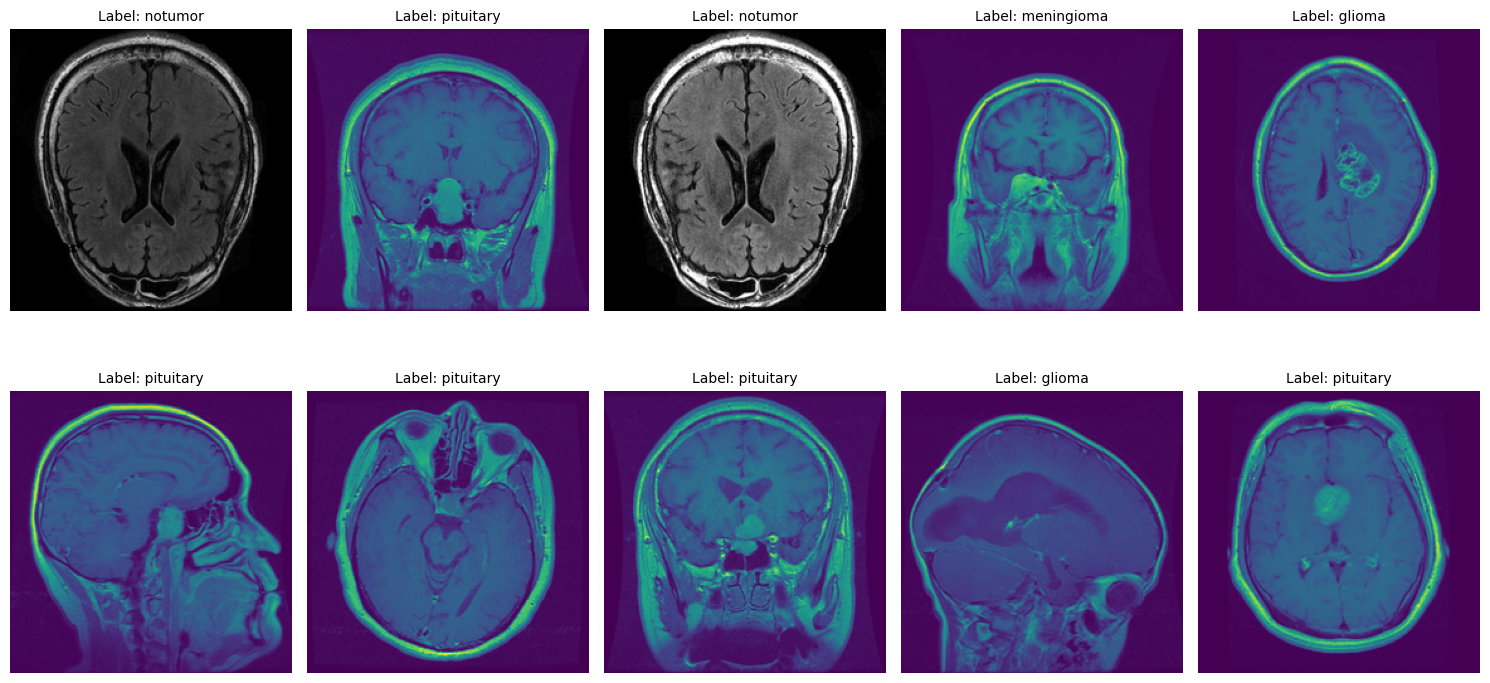

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


# Image Preprocessing (Helper Functions)

In [7]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Initialize label encoder once (not per batch)
unique_labels = os.listdir(train_dir)
label_encoder = LabelEncoder()
label_encoder.fit(unique_labels)

# Modified augmentation function (applied during training)
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    # Random transformations
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.7, 1.3))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.7, 1.3))
    image = image.rotate(random.uniform(-15, 15))
    image = np.array(image)
    return preprocess_input(image)  # VGG16-specific preprocessing

# Standard preprocessing (no augmentation for validation)
def preprocess_image(image):
    image = Image.fromarray(np.uint8(image))
    image = np.array(image)
    return preprocess_input(image)

# Split data into train/validation
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.2, stratify=train_labels)

# Modified data generator
def datagen(paths, labels, batch_size=12, augment=False):
    while True:  # Infinite loop for multiple epochs
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = []
            for path in batch_paths:
                image = load_img(path, target_size=(224, 224))
                image = np.array(image)
                if augment:
                    image = augment_image(image)
                else:
                    image = preprocess_image(image)
                batch_images.append(image)

            batch_labels = label_encoder.transform(labels[i:i + batch_size])
            yield np.array(batch_images), batch_labels

# Usage example:
train_gen = datagen(train_paths, train_labels, augment=True)
val_gen = datagen(val_paths, val_labels, augment=False)

# MODEL:
# WE ARE USING VGG16 FOR TRANSFER LEARNING.

The model is built on top of VGG16, which is a pre-trained convolutional neural network (CNN) for image classification.

First, the VGG16 model is loaded with input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet'. The input shape is set to match the size of the images in the dataset, which is 128x128 pixels. The include_top parameter is set to False, which means that the final fully-connected layers of VGG16 that perform the classification will not be included. The weights parameter is set to 'imagenet' which means that the model will be pre-trained with a dataset of 1.4 million images called imagenet

Next, the for layer in base_model.layers: loop is used to set all layers of the base_model (VGG16) to non-trainable, so that the weights of these layers will not be updated during training.

Then, the last three layers of the VGG16 model are set to trainable by using base_model.layers[-2].trainable = True,base_model.layers[-3].trainable = True and base_model.layers[-4].trainable = True

After that, a Sequential model is created and the VGG16 model is added to it with model.add(base_model).

Next, a Flatten layer is added to the model with model.add(Flatten()) which reshapes the output of the VGG16 model from a 3D tensor to a 1D tensor, so that it can be processed by the next layers of the model.

Then, a Dropout layer is added with model.add(Dropout(0.3)) which is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.

After that, a dense layer is added with 128 neurons and relu activation function is added with model.add(Dense(128, activation='relu')).

Next, another Dropout layer is added with model.add(Dropout(0.2))

Finally, the output dense layer is added with number of neurons equal to the number of unique labels and 'softmax' activation function is added with model.add(Dense(len(unique_labels), activation='softmax')). The 'softmax' activation function is used to give a probability distribution over the possible classes.

In [8]:
# --- Model Architecture & Training ---
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D, Activation, Input, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Import L2 Regularization
from tensorflow.keras.regularizers import l2

IMAGE_SIZE = 224

# 1. Load Base Model
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# 2. Freeze Layers (Cleaned up logic)
# First, freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Then, unfreeze the last 4 layers for fine-tuning
for layer in base_model.layers[-4:]:
    layer.trainable = True

# 3. Calculate Class Weights (if train_labels is available from previous cells)
if 'train_labels' in locals():
    unique_classes = np.unique(train_labels)
    class_weights_array = compute_class_weight('balanced', classes=unique_classes, y=train_labels)
    class_weights = dict(enumerate(class_weights_array))
else:
    print("Warning: train_labels not found. Class weights not calculated.")
    class_weights = None

# 4. Build Model with L2 Regularization
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5), # High dropout to reduce overfitting

    # --- L2 REGULARIZATION ADDED HERE ---
    # l2(0.01) penalizes large weights to reduce overfitting
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),

    Dropout(0.3),
    Dense(len(os.listdir(train_dir)), activation='softmax')
])

# 5. Compile
optimizer = Adam(learning_rate=1e-4, weight_decay=1e-6)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6. Train
# Ensure train_gen and val_gen were created in previous cells
batch_size = 20
steps_per_epoch = int(len(train_paths) / batch_size)
val_steps = int(len(val_paths) / batch_size)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=10, # You can increase this if early stopping handles it
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=3)
    ]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 1600s 7s/step - accuracy: 0.4066 - loss: 4.9116 - val_accuracy: 0.7193 - val_loss: 3.4590 - learning_rate: 1.0000e-04
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 1050s 5s/step - accuracy: 0.6456 - loss: 3.3338 - val_accuracy: 0.8874 - val_loss: 2.4254 - learning_rate: 1.0000e-04
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 28s 123ms/step - accuracy: 0.7911 - loss: 2.4686 - val_accuracy: 0.8889 - val_loss: 1.8704 - learning_rate: 1.0000e-04
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 41s 180ms/step - accuracy: 0.8545 - loss: 1.8923 - val_accuracy: 0.8652 - val_loss: 1.7374 - learning_rate: 1.0000e-04
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 27s 119ms/step - accuracy: 0.8652 - loss: 1.5701 - val_accuracy: 0.9123 - val_loss: 1.2763 - learning_rate: 1.0000e-04
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 28s 122ms/step - accuracy: 0.9062 - loss: 1.2553 - val_accuracy: 0.9298 - val_loss: 1.0728 - learning_rate: 1.0000e-

In [9]:
# ==========================================
# COMPLETE VGG16 TRAINING PIPELINE WITH L2
# ==========================================

import numpy as np
import os
import random
from PIL import Image, ImageEnhance

# Machine Learning Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning Imports
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.vgg16 import preprocess_input, VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2  # <--- CRITICAL IMPORT FOR REGULARIZATION

# 1. CONSTANTS
IMAGE_SIZE = 224
BATCH_SIZE = 20
EPOCHS = 10

# 2. DATA PREPARATION
# Note: Ensure 'train_paths' and 'train_labels' are loaded in memory before running this.
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=42
)

# 3. CLASS WEIGHTS & ENCODER
unique_classes = np.unique(train_labels)
class_weights_array = compute_class_weight('balanced', classes=unique_classes, y=train_labels)
class_weights = dict(enumerate(class_weights_array))

label_encoder = LabelEncoder()
label_encoder.fit(unique_classes)

# 4. DATA GENERATOR (With Augmentation)
def datagen(paths, labels, batch_size=12, augment=False):
    while True:
        indices = np.random.permutation(len(paths))
        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_paths = [paths[j] for j in batch_indices]
            batch_labels = [labels[j] for j in batch_indices]

            batch_images = []
            for path in batch_paths:
                try:
                    img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                    img = np.array(img)

                    if augment:
                        img = Image.fromarray(img)
                        # Random Flip
                        if random.random() > 0.5:
                            img = img.transpose(Image.FLIP_LEFT_RIGHT)
                        # Random Brightness
                        enhancer = ImageEnhance.Brightness(img)
                        img = enhancer.enhance(random.uniform(0.8, 1.2))
                        img = np.array(img)

                    img = preprocess_input(img)
                    batch_images.append(img)
                except Exception as e:
                    print(f"Error loading image {path}: {e}")
                    continue

            # Skip incomplete batches if necessary, or handle empty lists
            if not batch_images:
                continue

            batch_labels_encoded = label_encoder.transform(batch_labels)

            # Sample weights (optional, but good for imbalanced data)
            sample_weights = [class_weights[label] for label in batch_labels_encoded]

            yield np.array(batch_images), np.array(batch_labels_encoded), np.array(sample_weights)

# Initialize Generators
train_gen = datagen(train_paths, train_labels, batch_size=BATCH_SIZE, augment=True)
val_gen = datagen(val_paths, val_labels, batch_size=BATCH_SIZE, augment=False)

# 5. MODEL ARCHITECTURE
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freezing Strategy: Freeze all, then unfreeze the last 3 layers
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-3:]:
    layer.trainable = True

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    GlobalAveragePooling2D(),

    Dropout(0.5),

    # --- CORRECT L2 REGULARIZATION ---
    # We use l2(0.01) instead of the string 'l2'
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),

    Dropout(0.3),
    Dense(len(unique_classes), activation='softmax')
])

# 6. COMPILE
optimizer = Adam(learning_rate=1e-4, weight_decay=1e-6)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 7. TRAIN
steps_per_epoch = len(train_paths) // BATCH_SIZE
val_steps = len(val_paths) // BATCH_SIZE

print("Starting Training...")
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
    ]
)

# 8. EVALUATE (Optional, if test set exists)
if 'test_paths' in locals() and 'test_labels' in locals():
    print("Evaluating on Test Set...")
    test_gen = datagen(test_paths, test_labels, batch_size=BATCH_SIZE)
    test_steps = len(test_paths) // BATCH_SIZE
    test_loss, test_acc = model.evaluate(test_gen, steps=test_steps)
    print(f"\nTest Accuracy: {test_acc*100:.2f}%")

Starting Training...
Epoch 1/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 48s 183ms/step - accuracy: 0.5599 - loss: 4.8508 - val_accuracy: 0.8733 - val_loss: 3.2953 - learning_rate: 1.0000e-04
Epoch 2/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 81s 391ms/step - accuracy: 0.8033 - loss: 3.3585 - val_accuracy: 0.9022 - val_loss: 2.7261 - learning_rate: 1.0000e-04
Epoch 3/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 32s 174ms/step - accuracy: 0.8641 - loss: 2.6935 - val_accuracy: 0.9044 - val_loss: 2.2787 - learning_rate: 1.0000e-04
Epoch 4/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.8896 - loss: 2.2453 - val_accuracy: 0.9367 - val_loss: 1.8961 - learning_rate: 1.0000e-04
Epoch 5/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 38s 208ms/step - accuracy: 0.9100 - loss: 1.8852 - val_accuracy: 0.9441 - val_loss: 1.6253 - learning_rate: 1.0000e-04
Epoch 6/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.9337 - loss: 1.5701 - val_accuracy: 0.9385 - val_loss: 1.4247 - learning_rate: 1.0000e-04
Epoch 7/10
182/182 ━━━━━━

# Train and Val Plots

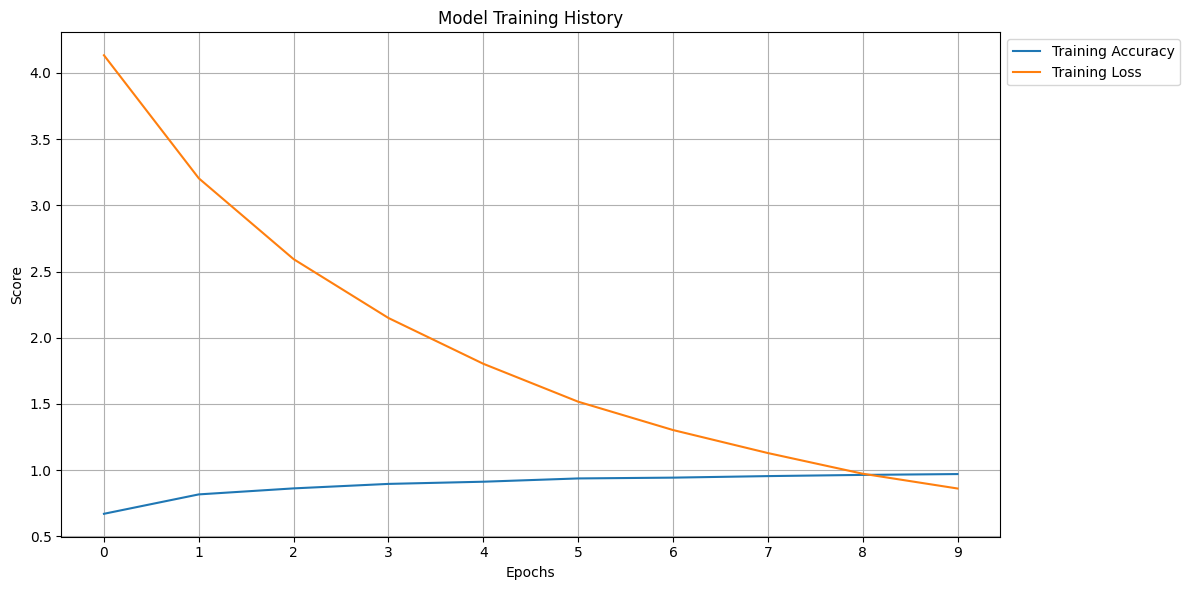

In [11]:
import matplotlib.pyplot as plt

# 1. Access history from the trained model
acc = history.history['accuracy']
loss = history.history['loss']

# 2. Define the range of epochs (Use the correct variable EPOCHS)
# If EPOCHS is not defined in this cell, we use the length of the history data
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# 3. Plot Accuracy and Loss
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, loss, label='Training Loss')

plt.title('Model Training History')
plt.xlabel('Epochs')
plt.ylabel('Score')

# 4. Fix the xticks error by using the correct range
plt.xticks(list(epochs_range))

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

# Model Classification Report

Evaluating model on 1311 images...
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step

--- Enhanced Classification Report ---
              precision    recall  f1-score   support

      glioma       0.99      0.91      0.95       300
  meningioma       0.93      0.90      0.91       306
     notumor       0.98      0.99      0.99       405
   pituitary       0.91      1.00      0.95       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



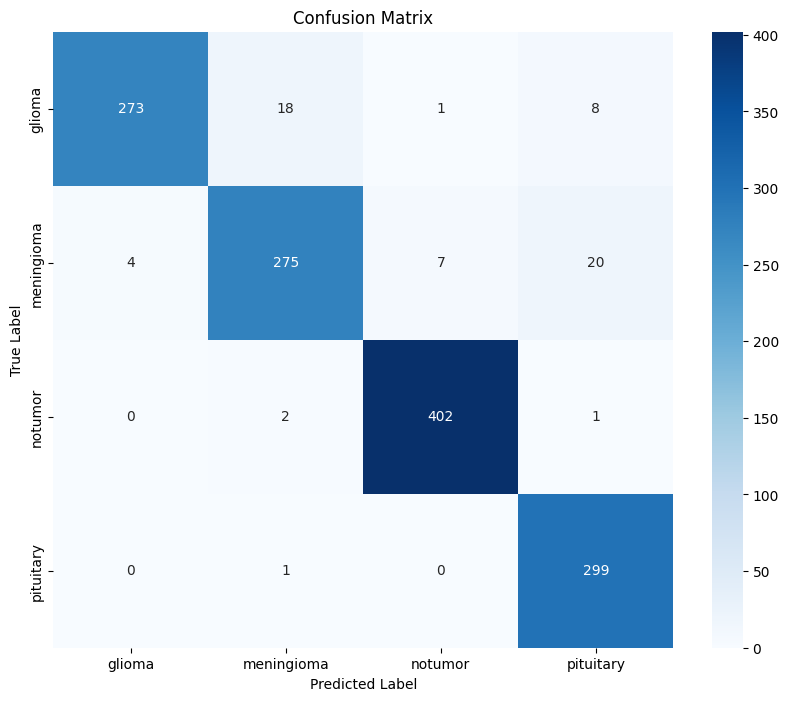

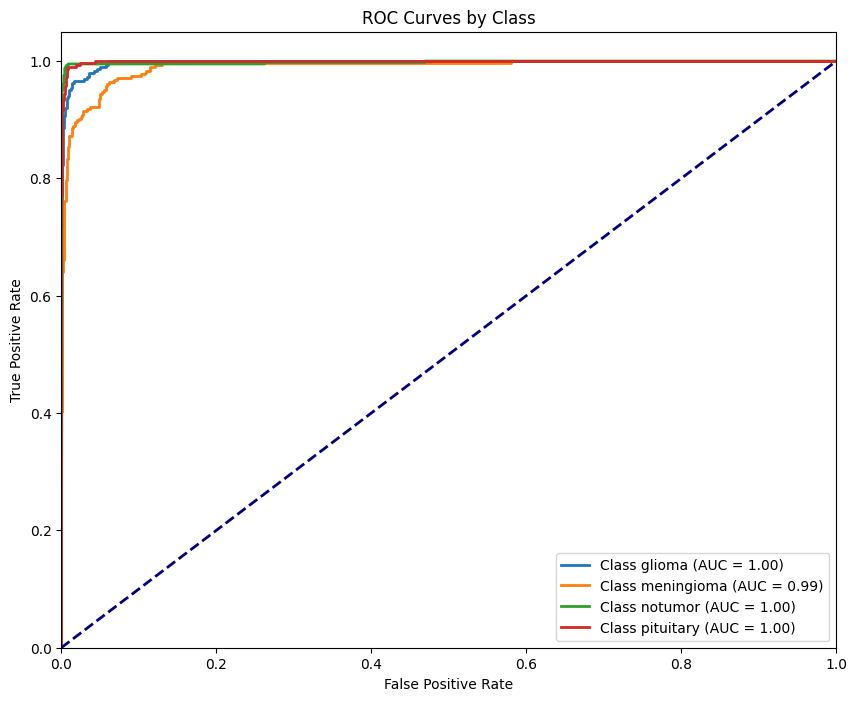

In [14]:
# ==========================================
# FINAL EVALUATION CELL (Report + Visuals)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, label_binarize
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. SETUP & PREPROCESSING
# ------------------------------------------
def preprocess_test_images(paths):
    images = []
    for path in paths:
        try:
            img = load_img(path, target_size=(224, 224))
            img = np.array(img)
            img = preprocess_input(img)  # VGG16 specific preprocessing
            images.append(img)
        except Exception as e:
            print(f"Error loading {path}: {e}")
    return np.array(images)

# Ensure label encoder is ready (assuming train_labels exists from training step)
# If loading a saved model without running training, you might need to manually define classes:
# label_encoder.classes_ = np.array(['glioma', 'meningioma', 'notumor', 'pituitary'])
if not hasattr(label_encoder, 'classes_'):
    print("Fitting Label Encoder...")
    label_encoder = LabelEncoder()
    label_encoder.fit(train_labels)

# 2. RUN PREDICTIONS
# ------------------------------------------
print(f"Evaluating model on {len(test_paths)} images...")

test_images = preprocess_test_images(test_paths)
test_labels_encoded = label_encoder.transform(test_labels)

# Get Probabilities and Classes
predictions_prob = model.predict(test_images)
predictions_class = np.argmax(predictions_prob, axis=1)

# 3. CLASSIFICATION REPORT
# ------------------------------------------
print("\n--- Enhanced Classification Report ---")
print(classification_report(test_labels_encoded, predictions_class, target_names=label_encoder.classes_))

# 4. CONFUSION MATRIX
# ------------------------------------------
plt.figure(figsize=(10, 8))
cm = confusion_matrix(test_labels_encoded, predictions_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. ROC CURVES (Multiclass)
# ------------------------------------------
# Binarize labels for ROC calculation
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(test_labels_encoded, classes=range(n_classes))

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], predictions_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves by Class')
plt.legend(loc="lower right")
plt.show()

## Error analysis vizualization

Found 62 misclassified images.


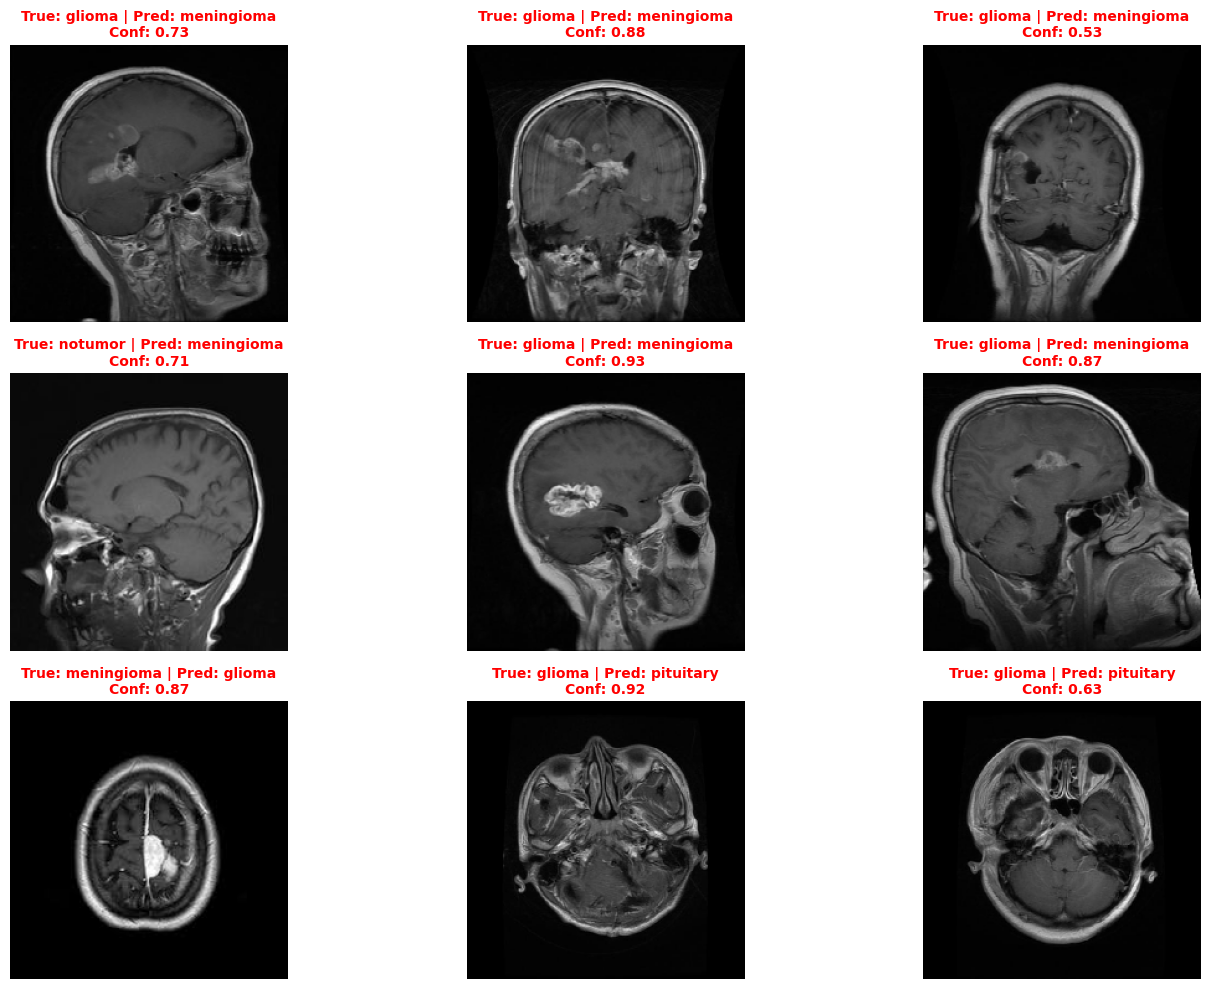

In [15]:
# ==========================================
# 6. ERROR ANALYSIS VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Helper function to reverse VGG16 preprocessing
def deprocess_vgg16_image(img_array):
    img = img_array.copy()
    # 1. Add the ImageNet mean (standard VGG16 stats)
    #    Note: Keras VGG16 preprocess subtracts these values:
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68

    # 2. Convert BGR (VGG default) back to RGB
    img = img[:, :, ::-1]

    # 3. Clip values to valid [0, 255] range and convert to integer
    img = np.clip(img, 0, 255).astype('uint8')
    return img

# Find indices of misclassified images
misclassified_indices = np.where(predictions_class != test_labels_encoded)[0]

print(f"Found {len(misclassified_indices)} misclassified images.")

# Plot up to 9 misclassified examples
num_images_to_show = min(9, len(misclassified_indices))
if num_images_to_show > 0:
    plt.figure(figsize=(15, 10))

    for i in range(num_images_to_show):
        idx = misclassified_indices[i]

        plt.subplot(3, 3, i + 1)

        # Display the corrected image
        original_img = deprocess_vgg16_image(test_images[idx])
        plt.imshow(original_img)

        # Get labels
        true_label = label_encoder.classes_[test_labels_encoded[idx]]
        pred_label = label_encoder.classes_[predictions_class[idx]]
        confidence = predictions_prob[idx][predictions_class[idx]]

        plt.title(f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2f}",
                  color='red', fontsize=10, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Great news! No misclassified images found (100% Accuracy on this set).")

## Class-Wise Accuracy Breakdown


--- Class-wise Accuracy ---
glioma         : 91.00%
meningioma     : 89.87%
notumor        : 99.26%
pituitary      : 99.67%


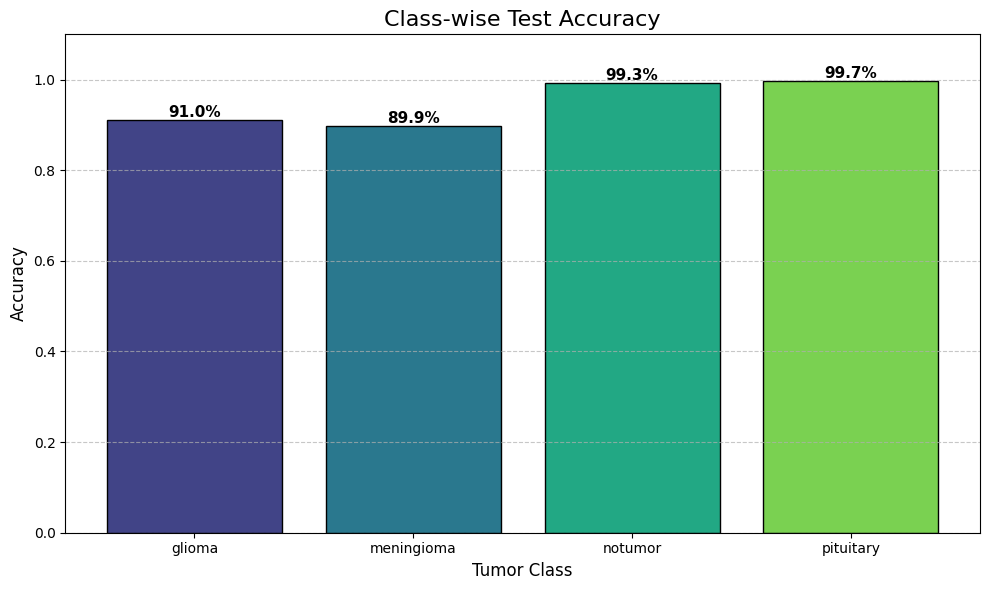

In [17]:
# ==========================================
# 8. CLASS-WISE ACCURACY BREAKDOWN (FIXED)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate Accuracy per Class
class_acc = {}

# We use 'predictions_class' to match the variable from the previous Evaluation Cell
for i, class_name in enumerate(label_encoder.classes_):
    mask = test_labels_encoded == i

    # Avoid division by zero if a class is missing
    if np.sum(mask) > 0:
        # CORRECTION HERE: changed 'predicted_classes' to 'predictions_class'
        class_acc[class_name] = np.mean(predictions_class[mask] == test_labels_encoded[mask])
    else:
        class_acc[class_name] = 0.0

# 2. Print Text Results
print("\n--- Class-wise Accuracy ---")
for class_name, acc in class_acc.items():
    print(f"{class_name.ljust(15)}: {acc:.2%}")

# 3. Visualize with Bar Chart
plt.figure(figsize=(10, 6))
colors = sns.color_palette('viridis', len(class_acc))

bars = plt.bar(class_acc.keys(), class_acc.values(), color=colors, edgecolor='black')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Class-wise Test Accuracy', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Tumor Class', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Confidence Distribution Analysis

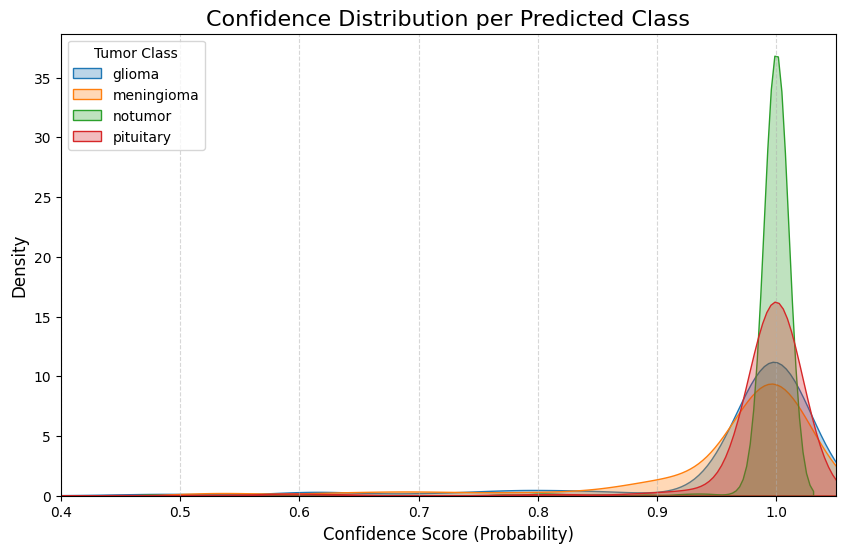

In [18]:
# ==========================================
# 9. CONFIDENCE DISTRIBUTION ANALYSIS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate Confidence Scores
# (Max probability for each prediction)
confidence_scores = np.max(predictions_prob, axis=1)

# 2. Plot Distribution
plt.figure(figsize=(10, 6))

for i, class_name in enumerate(label_encoder.classes_):
    # Select the confidence scores where the model predicted this class
    # we use 'predictions_class' (from previous cell) instead of 'predicted_classes'
    mask = predictions_class == i

    # We need at least 2 data points to plot a density curve
    if np.sum(mask) > 1:
        class_conf = confidence_scores[mask]
        # 'shade' is deprecated in new seaborn versions, used 'fill=True'
        sns.kdeplot(class_conf, label=class_name, fill=True, alpha=0.3)
    else:
        print(f"Skipping {class_name}: Not enough samples to plot distribution.")

plt.title('Confidence Distribution per Predicted Class', fontsize=16)
plt.xlabel('Confidence Score (Probability)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Tumor Class')
plt.xlim(0.4, 1.05) # Focus on the higher confidence range
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
!pip install opencv-python

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,550,990 (93.65 MB)

 Trainable params: 4,851,972 (18.51 MB)

 Non-trainable params: 9,995,072 (38.13 MB)

 Optimizer params: 9,703,946 (37.02 MB)

# Save & Load Model

In [ ]:
# from tensorflow.keras.models import load_model
# # Load the trained model
# model = load_model('vgg16_brain_tumor_detection_model.h5')

In [ ]:
# model.save('vgg16_brain_tumor_detection_model.h5')

# MRI Tumor Detection System

In [20]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# Ensure these match your label_encoder.classes_ order exactly
# If you used LabelEncoder earlier, print(label_encoder.classes_) to verify
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=224):
    """
    Function to detect tumor and display results using VGG16 preprocessing.
    """
    try:
        # 1. Load Image
        img_original = load_img(img_path, target_size=(image_size, image_size))

        # 2. Preprocess exactly how VGG16 was trained
        img_array = img_to_array(img_original)
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        img_processed = preprocess_input(img_array)    # VGG16 specific preprocessing

        # 3. Predict
        predictions = model.predict(img_processed)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        predicted_label = class_labels[predicted_class_index]

        # 4. Determine Result String
        if predicted_label == 'notumor':
            result_text = "Result: No Tumor Detected"
            color = 'green'
        else:
            result_text = f"Detected: {predicted_label}"
            color = 'red'

        # 5. Display
        plt.figure(figsize=(6, 6))
        plt.imshow(img_original) # Show original (human-readable) image
        plt.axis('off')
        plt.title(f"{result_text}\nConfidence: {confidence_score * 100:.2f}%",
                  color=color, fontsize=14, fontweight='bold')
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Example Usage:
# detect_and_display('/content/drive/MyDrive/.../some_test_image.jpg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


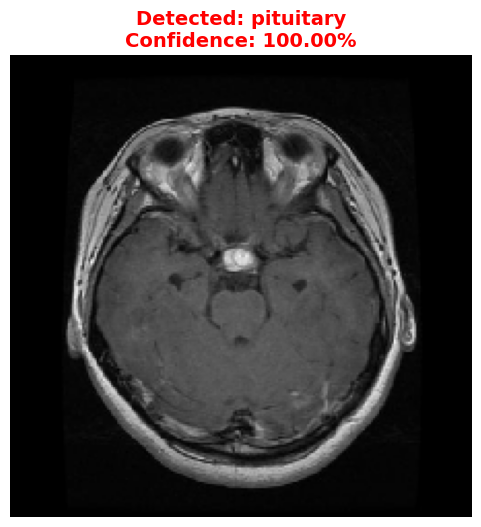

In [21]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Detection/Testing/pituitary/Te-pi_0035.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


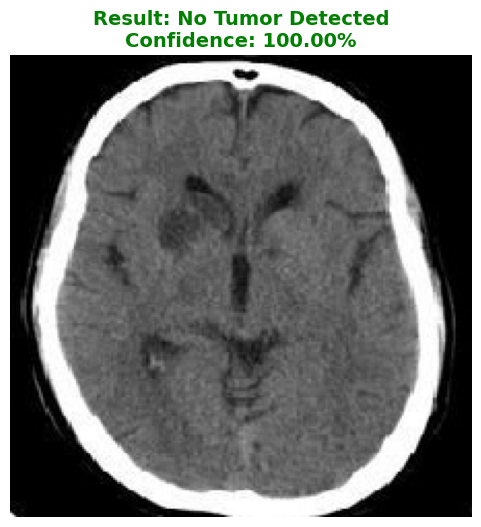

In [22]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Detection/Testing/notumor/Te-no_0010.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


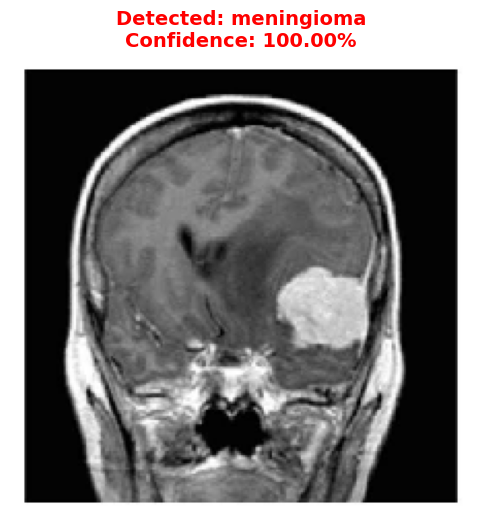

In [23]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Detection/Testing/meningioma/Te-me_0014.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


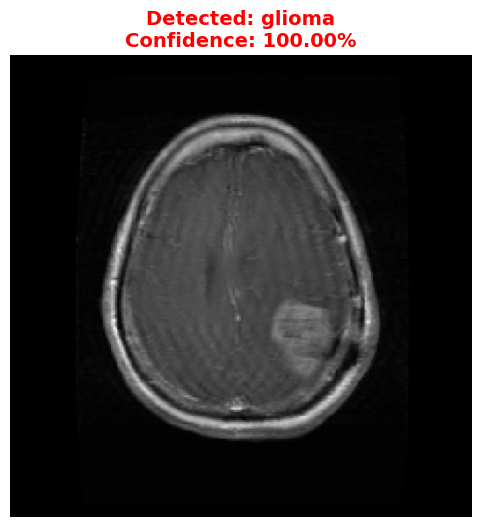

In [24]:
# Example usage
image_path = '/content/drive/MyDrive/MRI Detection/Testing/glioma/Te-gl_0023.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

In [ ]:
#model_save_path = '/content/drive/MyDrive/3rd_year_project-PR_591/vgg16_brain_tumor_detection_model.h5'
#model.save(model_save_path)